<a href="https://colab.research.google.com/github/malhathilleliarab-droid/BoneFractureClassification/blob/main/Copie_de_Copie_de_spinal_AI_project_version_4_2_1i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1

In [ ]:
import torch
print("Torch version :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -> Runtime > Change runtime type > GPU")


Torch version : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4


2

In [ ]:
!pip install -q pycocotools albumentations opencv-python-headless matplotlib pandas
print("Dependencies installed.")

Dependencies installed.




3



In [ ]:
import os, json, random, copy
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from pycocotools.coco import COCO
from pycocotools import mask as maskUtils

import albumentations as A

# Reproductibilité
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Imports OK | device =", device)

Imports OK | device = cuda


4

In [ ]:
%cd /content
!rm -rf Spinal-AI2024
!git clone https://github.com/Ernestchenchen/Spinal-AI2024.git

/content
Cloning into 'Spinal-AI2024'...
remote: Enumerating objects: 20090, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 20090 (delta 20), reused 4 (delta 4), pack-reused 20060 (from 1)
Receiving objects: 100% (20090/20090), 515.03 MiB | 12.93 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Updating files: 100% (20008/20008), done.


5

In [ ]:
DATASET_ROOT = Path("/content/Spinal-AI2024")
assert DATASET_ROOT.exists(), "Le dossier n'existe pas — le clonage a échoué."
print("Racine :", DATASET_ROOT)
for item in sorted(DATASET_ROOT.iterdir()):
    print("  ", item.name)

Racine : /content/Spinal-AI2024
   .git
   .gitignore
   Cobb_spinal-AI2024-test_gt.txt
   Cobb_spinal-AI2024-train_gt.txt
   README.md
   Spinal-AI2024-subset1
   Spinal-AI2024-subset2
   Spinal-AI2024-subset3
   Spinal-AI2024-subset4
   Spinal-AI2024-subset5
   Spinal_AI2024_test_annotation.zip
   Spinal_AI2024_train__annotation.zip
   figs
   image_similarity_checklist.xlsx


6

In [ ]:
import zipfile

def safe_extract(zip_path, out_dir):
    out_dir = Path(out_dir)
    if zip_path.exists() and not out_dir.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
        print("Extracted:", out_dir)
    else:
        print("Already extracted or ZIP missing:", out_dir)

safe_extract(DATASET_ROOT / "Spinal_AI2024_train__annotation.zip", DATASET_ROOT / "train_annotations")
safe_extract(DATASET_ROOT / "Spinal_AI2024_test_annotation.zip",  DATASET_ROOT / "test_annotations")

Extracted: /content/Spinal-AI2024/train_annotations
Extracted: /content/Spinal-AI2024/test_annotations


7

In [ ]:
json_files = list(DATASET_ROOT.rglob("*.json"))
TRAIN_JSON = next((p for p in json_files if "train" in p.name.lower()), None)
TEST_JSON  = next((p for p in json_files if "test"  in p.name.lower()), None)
print("TRAIN_JSON:", TRAIN_JSON)
print("TEST_JSON :", TEST_JSON)
assert TRAIN_JSON and TEST_JSON, "train/test JSON not found."

TRAIN_JSON: /content/Spinal-AI2024/train_annotations/Spinal_AI2024_train__annotation.json
TEST_JSON : /content/Spinal-AI2024/test_annotations/Spinal_AI2024_test_annotation.json


8

In [ ]:
with open(TRAIN_JSON) as f:
    train_data = json.load(f)
print("Keys:", list(train_data.keys()))
print("Images      :", len(train_data["images"]))
print("Annotations :", len(train_data["annotations"]))
print("Categories  :", len(train_data["categories"]))

Keys: ['images', 'annotations', 'categories']
Images      : 16000
Annotations : 273450
Categories  : 1


9

In [ ]:
print("Raw category(ies) from JSON:")
for c in train_data["categories"]:
    print("  ", c)

CATEGORY_REMAP = {1: 1}
CLASS_NAMES    = {0: "background", 1: "vertebra"}
print("\nApplied remap:", CATEGORY_REMAP, "| classes:", CLASS_NAMES)

Raw category(ies) from JSON:
   {'supercategory': 'text', 'id': 1, 'name': 'text'}

Applied remap: {1: 1} | classes: {0: 'background', 1: 'vertebra'}


10

In [ ]:
images_by_id  = {img["id"]: img for img in train_data["images"]}
anns_by_image = defaultdict(list)
for ann in train_data["annotations"]:
    anns_by_image[ann["image_id"]].append(ann)
print("Indexed images       :", len(images_by_id))
print("Images with annotations:", len(anns_by_image))

Indexed images       : 16000
Images with annotations: 15999


11

In [ ]:
IMAGE_DIRS = [DATASET_ROOT / f"Spinal-AI2024-subset{i}" for i in range(1, 6)]

def find_image_path(file_name):
    for d in IMAGE_DIRS:
        p = d / file_name
        if p.exists():
            return p
    return None

def coco_annotation_to_mask(ann, height, width):
    seg = ann["segmentation"]
    if isinstance(seg, list):
        rles = maskUtils.frPyObjects(seg, height, width)
        rle = maskUtils.merge(rles)
    elif isinstance(seg, dict) and isinstance(seg.get("counts"), list):
        rle = maskUtils.frPyObjects(seg, height, width)
    else:
        rle = seg
    m = maskUtils.decode(rle)
    if m.ndim == 3:
        m = np.any(m, axis=2)
    return m.astype(np.uint8)

_id   = next(iter(anns_by_image))
_info = images_by_id[_id]
_p    = find_image_path(_info["file_name"])
_m    = coco_annotation_to_mask(anns_by_image[_id][0], _info["height"], _info["width"])
print("Test path:", _p)
print("Test mask:", _m.shape, "unique values:", np.unique(_m))

Test path: /content/Spinal-AI2024/Spinal-AI2024-subset1/000001.jpg
Test mask: (512, 512) unique values: [0 1]


12

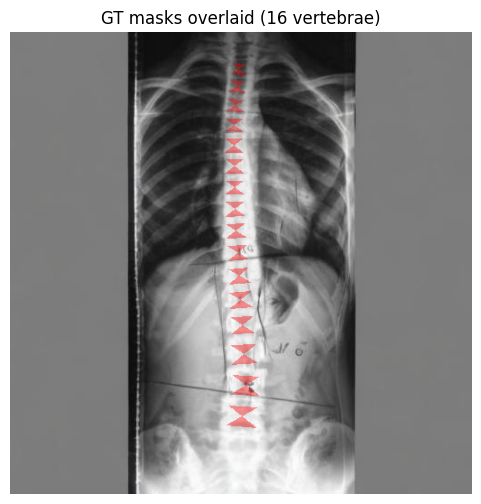

In [ ]:
sid  = _id
info = images_by_id[sid]
img  = cv2.cvtColor(cv2.imread(str(find_image_path(info["file_name"]))), cv2.COLOR_BGR2RGB)
overlay = img.copy()
for ann in anns_by_image[sid]:
    m = coco_annotation_to_mask(ann, info["height"], info["width"])
    overlay[m == 1] = (0.6 * overlay[m == 1] + 0.4 * np.array([255, 0, 0])).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(overlay); plt.axis("off")
plt.title(f"GT masks overlaid ({len(anns_by_image[sid])} vertebrae)")
plt.show()

13

In [ ]:
import albumentations as A
import cv2

train_transform = A.Compose([
A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
A.ShiftScaleRotate(
shift_limit=0.05, scale_limit=0.05, rotate_limit=8,
border_mode=cv2.BORDER_CONSTANT,
fill=0, # ← "fill" and not "fill_value" in Albumentations >= 1.4
p=0.4
),
A.GaussNoise(p=0.2), # ← remove var_limit, parameter renamed
])
val_transform = None
print("Corrected augmentation pipelines (no warnings).")



Corrected augmentation pipelines (no warnings).


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


14

In [ ]:
class SpineSegmentationDataset(Dataset):
    def __init__(self, image_ids, images_by_id, anns_by_image, image_dirs, transform=None):
        self.image_ids    = list(image_ids)
        self.images_by_id = images_by_id
        self.anns_by_image = anns_by_image
        self.image_dirs   = image_dirs
        self.transform    = transform

    def __len__(self):
        return len(self.image_ids)

    def _find_path(self, file_name):
        for d in self.image_dirs:
            p = d / file_name
            if p.exists():
                return p
        return None

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.images_by_id[image_id]
        H, W = info["height"], info["width"]

        path = self._find_path(info["file_name"])
        if path is None:
            img = np.zeros((H, W, 3), dtype=np.uint8)
        else:
            raw = cv2.imread(str(path))
            img = np.zeros((H, W, 3), dtype=np.uint8) if raw is None \
                  else cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

        masks = []
        for ann in self.anns_by_image.get(image_id, []):
            m = coco_annotation_to_mask(ann, H, W)
            if m.sum() > 0:
                masks.append(m)

        if self.transform is not None and len(masks) > 0:
            aug = self.transform(image=img, masks=masks)
            img, masks = aug["image"], aug["masks"]

        boxes, kept = [], []
        for m in masks:
            m = np.asarray(m)
            ys, xs = np.where(m > 0)
            if xs.size == 0 or ys.size == 0:
                continue
            x1, x2, y1, y2 = xs.min(), xs.max(), ys.min(), ys.max()
            if x2 > x1 and y2 > y1:
                boxes.append([float(x1), float(y1), float(x2), float(y2)])
                kept.append(m.astype(np.uint8))

        if len(boxes) == 0:
            dummy = np.zeros((H, W), dtype=np.uint8); dummy[0:2, 0:2] = 1
            boxes, kept = [[0.0, 0.0, 1.0, 1.0]], [dummy]

        boxes   = torch.as_tensor(boxes, dtype=torch.float32)
        masks_t = torch.as_tensor(np.stack(kept), dtype=torch.uint8)
        labels  = torch.ones((len(boxes),), dtype=torch.int64)
        area    = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        image_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        target = {
            "boxes": boxes, "labels": labels, "masks": masks_t,
            "image_id": torch.tensor([image_id]),
            "area": area,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }
        return image_tensor, target

print("SpineSegmentationDataset defined.")

SpineSegmentationDataset defined.


15

In [ ]:
all_ids = list(anns_by_image.keys())
random.Random(SEED).shuffle(all_ids)
split = int(0.9 * len(all_ids))
train_ids, val_ids = all_ids[:split], all_ids[split:]

train_dataset = SpineSegmentationDataset(train_ids, images_by_id, anns_by_image, IMAGE_DIRS, train_transform)
val_dataset   = SpineSegmentationDataset(val_ids,   images_by_id, anns_by_image, IMAGE_DIRS, val_transform)

with open(TEST_JSON) as f:
    test_data = json.load(f)
test_images_by_id  = {img["id"]: img for img in test_data["images"]}
test_anns_by_image = defaultdict(list)
for ann in test_data["annotations"]:
    test_anns_by_image[ann["image_id"]].append(ann)
test_ids = list(test_anns_by_image.keys())
test_dataset = SpineSegmentationDataset(test_ids, test_images_by_id, test_anns_by_image, IMAGE_DIRS, val_transform)

print("Train:", len(train_dataset), "| Val:", len(val_dataset), "| Test:", len(test_dataset))

Train: 14399 | Val: 1600 | Test: 4000


16

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn)
print("DataLoaders created.")

DataLoaders created.


17

Images/batch: 2 | img0 shape: torch.Size([3, 512, 512])
Boxes0: torch.Size([16, 4]) | Masks0: torch.Size([16, 512, 512])


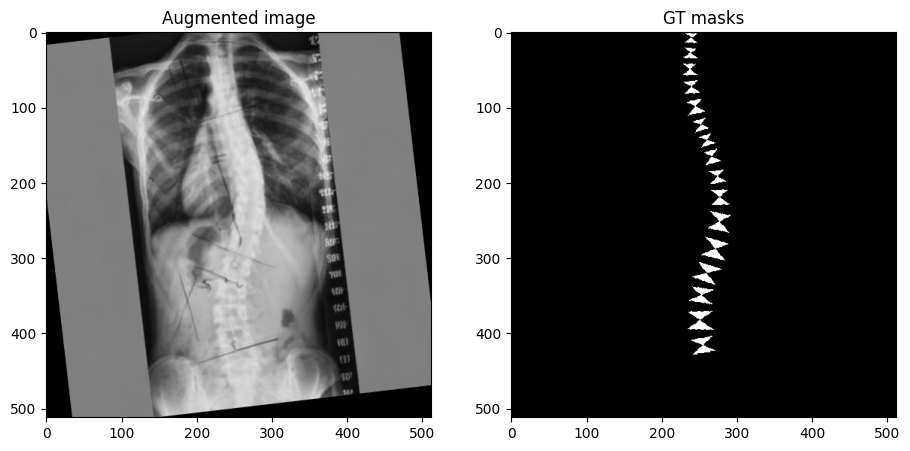

In [ ]:
images, targets = next(iter(train_loader))
print("Images/batch:", len(images), "| img0 shape:", images[0].shape)
print("Boxes0:", targets[0]["boxes"].shape, "| Masks0:", targets[0]["masks"].shape)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(images[0].permute(1, 2, 0).numpy()); ax[0].set_title("Augmented image")
ax[1].imshow(targets[0]["masks"].sum(0).numpy(), cmap="gray"); ax[1].set_title("GT masks")
plt.show()

18

In [ ]:
NUM_CLASSES = 2
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
in_feat = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
in_feat_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, NUM_CLASSES)
model.to(device)
print("Model ready on:", device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 182MB/s]


Model ready on: cuda


19

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
print("AdamW optimizer + CosineAnnealingLR scheduler created.")

AdamW optimizer + CosineAnnealingLR scheduler created.


20

In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch, print_freq=200):
    model.train()
    running = 0.0
    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        running += losses.item()
        if i % print_freq == 0:
            print(f"  Epoch {epoch} | iter {i}/{len(loader)} | loss {losses.item():.4f}")
    return running / len(loader)

21

In [ ]:
@torch.no_grad()
def evaluate_loss(model, loader, device):
    model.train()
    total = 0.0
    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total += sum(loss_dict.values()).item()
    model.eval()
    return total / len(loader)

22

In [ ]:
NUM_EPOCHS = 1
best_val = float("inf")
best_wts = None
train_loss_history, val_loss_history = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    tr = train_one_epoch(model, optimizer, train_loader, device, epoch)
    vl = evaluate_loss(model, val_loader, device)
    lr_scheduler.step()
    train_loss_history.append(tr)
    val_loss_history.append(vl)
    print(f"Epoch {epoch}/{NUM_EPOCHS} | train {tr:.4f} | val {vl:.4f}")
    if vl < best_val:
        best_val = vl
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, "/content/maskrcnn_spine_best.pth")
        print(f"   ✔ Best model saved (val={best_val:.4f})")

if best_wts is not None:
    model.load_state_dict(best_wts)
print("Training done. Best model reloaded.")

  Epoch 1 | iter 0/7200 | loss 7.3838
  Epoch 1 | iter 200/7200 | loss 0.8829
  Epoch 1 | iter 400/7200 | loss 0.8102
  Epoch 1 | iter 600/7200 | loss 0.7978
  Epoch 1 | iter 800/7200 | loss 0.7251
  Epoch 1 | iter 1000/7200 | loss 0.8196
  Epoch 1 | iter 1200/7200 | loss 0.5799
  Epoch 1 | iter 1400/7200 | loss 0.8343
  Epoch 1 | iter 1600/7200 | loss 1.2100
  Epoch 1 | iter 1800/7200 | loss 0.6406
  Epoch 1 | iter 2000/7200 | loss 0.6856
  Epoch 1 | iter 2200/7200 | loss 0.5096
  Epoch 1 | iter 2400/7200 | loss 0.5291
  Epoch 1 | iter 2600/7200 | loss 0.6410
  Epoch 1 | iter 2800/7200 | loss 0.5586
  Epoch 1 | iter 3000/7200 | loss 0.8726
  Epoch 1 | iter 3200/7200 | loss 0.5172
  Epoch 1 | iter 3400/7200 | loss 0.7242
  Epoch 1 | iter 3600/7200 | loss 0.9587
  Epoch 1 | iter 3800/7200 | loss 0.5709
  Epoch 1 | iter 4000/7200 | loss 0.8335
  Epoch 1 | iter 4200/7200 | loss 0.5782
  Epoch 1 | iter 4400/7200 | loss 0.7313
  Epoch 1 | iter 4600/7200 | loss 0.4664
  Epoch 1 | iter 4800/7

23

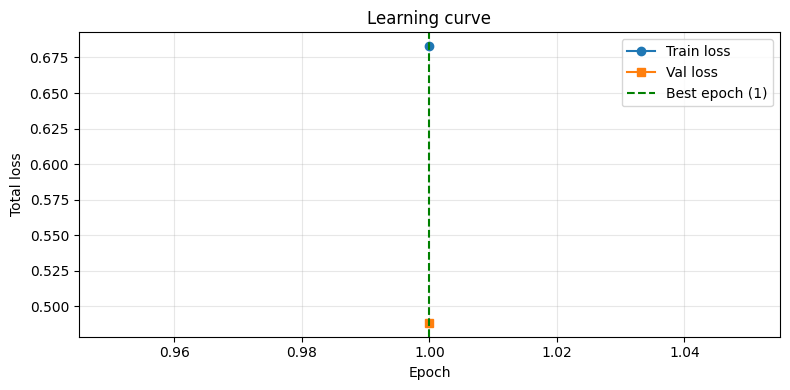

Best epoch: 1 | min val loss: 0.4884


In [ ]:
ep      = range(1, len(train_loss_history) + 1)
best_ep = int(np.argmin(val_loss_history)) + 1
plt.figure(figsize=(8, 4))
plt.plot(ep, train_loss_history, "o-", label="Train loss")
plt.plot(ep, val_loss_history,   "s-", label="Val loss")
plt.axvline(best_ep, color="green", ls="--", label=f"Best epoch ({best_ep})")
plt.xlabel("Epoch"); plt.ylabel("Total loss"); plt.title("Learning curve")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Best epoch:", best_ep, "| min val loss:", round(min(val_loss_history), 4))

24

Detections kept: 17


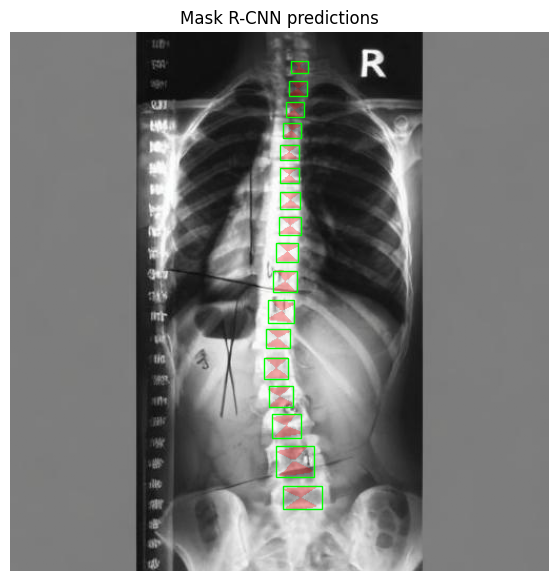

In [ ]:
model.eval()
val_img, _ = val_dataset[0]
with torch.no_grad():
    pred = model([val_img.to(device)])[0]

keep  = pred["scores"].cpu().numpy() >= 0.5
boxes = pred["boxes"].cpu().numpy()[keep]
masks = pred["masks"].cpu().numpy()[keep]
print("Detections kept:", len(boxes))

img_np = val_img.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 7)); ax.imshow(img_np)
for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i]
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", lw=1))
    m = masks[i, 0] > 0.5
    ax.imshow(np.ma.masked_where(~m, m), alpha=0.3, cmap="autumn")
ax.set_title("Mask R-CNN predictions"); ax.axis("off"); plt.show()

25

In [ ]:
import re

TRAIN_COBB_GT = DATASET_ROOT / "Cobb_spinal-AI2024-train_gt.txt"
TEST_COBB_GT  = DATASET_ROOT / "Cobb_spinal-AI2024-test_gt.txt"

def load_cobb_gt(filepath, images_by_id=None, verbose=True):
    gt = {}
    if not os.path.exists(filepath):
        print(f"[WARNING] File not found: {filepath}")
        return gt
    filename_to_id = {}
    if images_by_id is not None:
        for img_id, info in images_by_id.items():
            fname = Path(info["file_name"]).name
            filename_to_id[fname] = img_id
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = [l.strip() for l in f if l.strip() and not l.strip().startswith("#")]
    if verbose:
        print(f"=== {os.path.basename(filepath)} — first 5 lines ===")
        for l in lines[:5]:
            print("   ", repr(l))
    matched, unmatched = 0, 0
    for line in lines:
        parts = line.split(",")
        if len(parts) < 4:
            continue
        fname = parts[0].strip()
        try:
            angles = [float(x) for x in parts[1:4]]
        except ValueError:
            continue
        img_id = filename_to_id.get(fname)
        if img_id is None:
            unmatched += 1
            continue
        gt[img_id] = {
            "PT": angles[0], "MT": angles[1], "TL_L": angles[2],
            "max_cobb": max(abs(a) for a in angles),
        }
        matched += 1
    print(f"-> {matched} GT entries matched by filename | {unmatched} unmatched")
    return gt

train_cobb_gt = load_cobb_gt(TRAIN_COBB_GT, images_by_id=images_by_id)
test_cobb_gt  = load_cobb_gt(TEST_COBB_GT,  images_by_id=test_images_by_id)

=== Cobb_spinal-AI2024-train_gt.txt — first 5 lines ===
    '000001.jpg,2.87,11.01,8.87'
    '000002.jpg,3.18,9.35,16.48'
    '000003.jpg,7.14,16.33,11.51'
    '000004.jpg,4.53,19.2,26.7'
    '000005.jpg,5.04,6.71,5.87'
-> 15999 GT entries matched by filename | 0 unmatched
=== Cobb_spinal-AI2024-test_gt.txt — first 5 lines ===
    '016001.jpg,0.0,4.09,12.45'
    '016002.jpg,7.77,21.09,24.34'
    '016003.jpg,5.8,11.17,15.37'
    '016004.jpg,0.0,11.94,20.01'
    '016005.jpg,9.97,16.88,20.77'
-> 4000 GT entries matched by filename | 0 unmatched


26

In [ ]:
def get_vertebra_endplates(binary_mask):
    ys, xs = np.where(binary_mask > 0)
    if len(xs) < 10:
        return None
    cx, cy = float(xs.mean()), float(ys.mean())
    y_top_thresh = float(ys.min()) + 0.15 * (ys.max() - ys.min())
    top_mask = ys <= y_top_thresh
    top_xs, top_ys = xs[top_mask].astype(float), ys[top_mask].astype(float)
    y_bot_thresh = float(ys.max()) - 0.15 * (ys.max() - ys.min())
    bot_mask = ys >= y_bot_thresh
    bot_xs, bot_ys = xs[bot_mask].astype(float), ys[bot_mask].astype(float)

    def fit_endplate(ex, ey):
        if len(ex) < 3 or np.std(ex) < 1.0:
            x_min, x_max = float(ex.min()), float(ex.max())
            y_mean = float(ey.mean())
            return 0.0, ((x_min, y_mean), (x_max, y_mean))
        m, b = np.polyfit(ex, ey, 1)
        x_min, x_max = float(ex.min()), float(ex.max())
        return float(m), ((x_min, m * x_min + b), (x_max, m * x_max + b))

    up_m, up_line = fit_endplate(top_xs, top_ys)
    lo_m, lo_line = fit_endplate(bot_xs, bot_ys)
    return {
        "upper_slope": up_m, "lower_slope": lo_m,
        "upper_line": up_line, "lower_line": lo_line,
        "cx": cx, "cy": cy,
        "area": int(binary_mask.sum())
    }
print("get_vertebra_endplates defined.")

get_vertebra_endplates defined.


27

In [ ]:
def extract_vertebra_geometry(masks_pred, scores, score_thr=0.5, mask_thr=0.5, nms_dist=15):
    candidates = []
    for i in range(len(masks_pred)):
        if scores[i] < score_thr:
            continue
        m = (masks_pred[i, 0] > mask_thr).astype(np.uint8)
        g = get_vertebra_endplates(m)
        if g is None:
            continue
        g["score"] = float(scores[i])
        candidates.append(g)
    candidates.sort(key=lambda v: v["cy"])
    kept = []
    for c in candidates:
        if not kept or abs(c["cy"] - kept[-1]["cy"]) > nms_dist:
            kept.append(c)
        elif c["score"] > kept[-1]["score"]:
            kept[-1] = c
    return kept
print("extract_vertebra_geometry defined (spatial NMS, nms_dist=15px).")

extract_vertebra_geometry defined (spatial NMS, nms_dist=15px).


28

In [ ]:
def compute_cobb_angle(verts):
    n = len(verts)
    if n < 3:
        return None, None, None
    best_angle = -1.0
    best_i, best_j = None, None
    for i in range(n - 1):
        m_u = verts[i]["upper_slope"]
        if np.isinf(m_u):
            continue
        for j in range(i + 1, n):
            m_l = verts[j]["lower_slope"]
            if np.isinf(m_l):
                continue
            denom = 1.0 + m_u * m_l
            if abs(denom) < 1e-6:
                angle = 90.0
            else:
                angle = abs(np.degrees(np.arctan(abs(m_u - m_l) / abs(denom))))
            if angle > best_angle:
                best_angle = angle
                best_i, best_j = i, j
    if best_angle < 0:
        return None, None, None
    return best_angle, best_i, best_j

def classify_scoliosis(angle):
    if angle is None: return "Unknown"
    if angle < 10:    return "No scoliosis"
    if angle < 25:    return "Mild"
    if angle <= 40:   return "Moderate"
    return "Severe"

print("compute_cobb_angle + classify_scoliosis defined.")

compute_cobb_angle + classify_scoliosis defined.


29

In [ ]:
model.eval()
val_img, _ = val_dataset[0]
with torch.no_grad():
    p = model([val_img.to(device)])[0]

sc = p["scores"].cpu().numpy(); mk = p["masks"].cpu().numpy()
verts = extract_vertebra_geometry(mk, sc)
print(f"Vertebrae detected: {len(verts)}")
for i, v in enumerate(verts):
    print(f"  V{i+1:02d} | cy={v['cy']:6.1f} | upper={v['upper_slope']:+.4f} | lower={v['lower_slope']:+.4f}")

cobb, ui, li = compute_cobb_angle(verts)
print(f"\nCobb angle: {cobb:.2f}°  ->  {classify_scoliosis(cobb)}")

Vertebrae detected: 17
  V01 | cy=  32.9 | upper=-0.0000 | lower=-0.0130
  V02 | cy=  53.2 | upper=+0.0532 | lower=+0.0092
  V03 | cy=  73.3 | upper=+0.0714 | lower=+0.0319
  V04 | cy=  93.4 | upper=+0.0910 | lower=+0.0454
  V05 | cy= 113.8 | upper=+0.0062 | lower=+0.0000
  V06 | cy= 134.8 | upper=+0.0075 | lower=+0.0080
  V07 | cy= 159.1 | upper=+0.0000 | lower=-0.0067
  V08 | cy= 183.1 | upper=+0.0176 | lower=-0.0000
  V09 | cy= 208.9 | upper=+0.0640 | lower=+0.0117
  V10 | cy= 236.5 | upper=+0.0573 | lower=+0.0500
  V11 | cy= 264.9 | upper=+0.1060 | lower=+0.0840
  V12 | cy= 290.6 | upper=+0.0512 | lower=+0.0512
  V13 | cy= 318.7 | upper=-0.0047 | lower=-0.0047
  V14 | cy= 346.1 | upper=-0.0728 | lower=-0.0549
  V15 | cy= 374.0 | upper=-0.1120 | lower=-0.0849
  V16 | cy= 407.6 | upper=-0.1162 | lower=-0.0794
  V17 | cy= 441.8 | upper=-0.0631 | lower=-0.0387

Cobb angle: 10.90°  ->  Mild


30

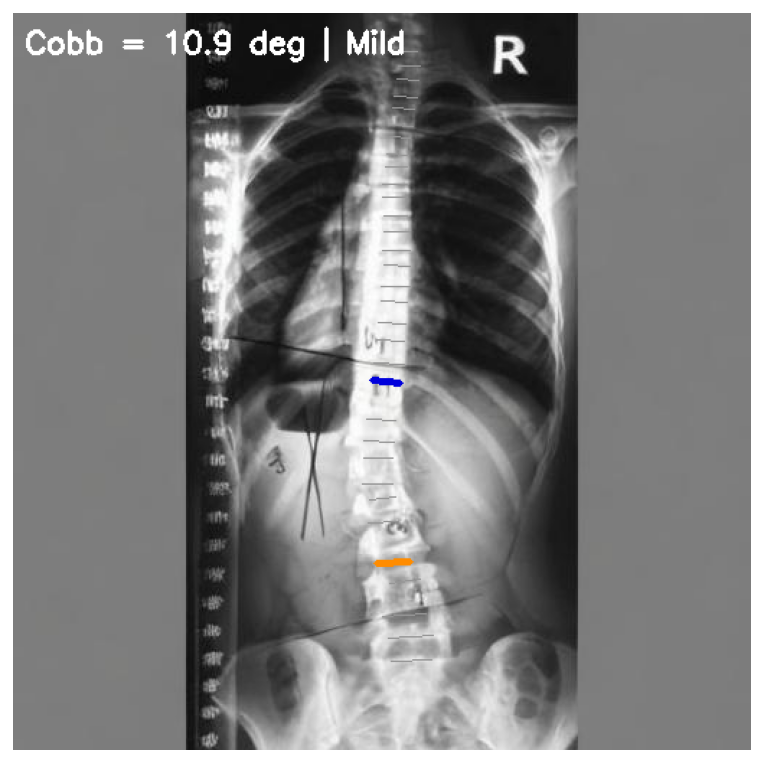

In [ ]:
def visualize_cobb(img_np, verts, u_idx, l_idx, cobb, severity):
    vis = (np.clip(img_np, 0, 1) * 255).astype(np.uint8)
    vis = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)

    def draw_line(line, color, w):
        if line is None: return
        (x1, y1), (x2, y2) = line
        cv2.line(vis, (int(x1), int(y1)), (int(x2), int(y2)), color, w)

    for i, v in enumerate(verts):
        if i == u_idx:
            draw_line(v["upper_line"], (220, 0, 0), 3)
        elif i == l_idx:
            draw_line(v["lower_line"], (0, 140, 255), 3)
        else:
            draw_line(v["upper_line"], (150, 150, 150), 1)
            draw_line(v["lower_line"], (150, 150, 150), 1)

    label = f"Cobb = {cobb:.1f} deg | {severity}" if cobb else "Not computed"
    cv2.putText(vis, label, (8, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    plt.figure(figsize=(6, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.tight_layout(); plt.show()

if cobb is not None:
    visualize_cobb(val_img.permute(1, 2, 0).cpu().numpy(), verts, ui, li, cobb, classify_scoliosis(cobb))

31

In [ ]:
model.eval()
NUM_EVAL = min(20, len(val_dataset))
results = []
for idx in range(NUM_EVAL):
    vimg, vtgt = val_dataset[idx]
    with torch.no_grad():
        pr = model([vimg.to(device)])[0]
    verts_i = extract_vertebra_geometry(pr["masks"].cpu().numpy(), pr["scores"].cpu().numpy())
    cobb_i, u_i, l_i = compute_cobb_angle(verts_i)
    img_id = int(vtgt["image_id"].item())
    gt = train_cobb_gt.get(img_id, {}).get("max_cobb", None)
    results.append({"image_id": img_id, "n_verts": len(verts_i),
                    "cobb": round(cobb_i, 2) if cobb_i else None,
                    "gt_cobb": round(gt, 2) if gt is not None else None,
                    "severity": classify_scoliosis(cobb_i)})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
common = df_results.dropna(subset=["cobb", "gt_cobb"])
if len(common):
    print(f"\nMAE (val, predicted vs GT): {(common['cobb'] - common['gt_cobb']).abs().mean():.2f}° "
          f"over {len(common)} images")

 image_id  n_verts  cobb  gt_cobb     severity
    11534       17 10.90    22.76         Mild
    10385       17  8.79    17.54 No scoliosis
    12459       19  8.79    20.46 No scoliosis
    15647       17  9.27    16.33 No scoliosis
     7111       17 12.73    20.74         Mild
     1481       17  6.49    14.57 No scoliosis
    12237       18  8.66    13.79 No scoliosis
    14801       17  8.21    12.55 No scoliosis
     4709       19  5.71    12.66 No scoliosis
    11215       18  9.66    20.57 No scoliosis
    10342       18  7.49    16.99 No scoliosis
     3847       16 11.68    18.75         Mild
     1122       18  3.57    10.91 No scoliosis
    10118       18 13.88    27.79         Mild
      589       17 15.55    26.61         Mild
     8866       17 13.41    23.91         Mild
    15724       18  7.76    14.91 No scoliosis
     7995       17  9.66    18.33 No scoliosis
    12444       18  4.87    10.21 No scoliosis
    11777       19  8.19    15.26 No scoliosis

MAE (val, pr

32

In [ ]:
def iou_single(a, b):
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def dice_single(a, b):
    inter = np.logical_and(a, b).sum(); denom = a.sum() + b.sum()
    return (2 * inter) / denom if denom > 0 else 0.0

def evaluate_segmentation(model, dataset, device, n_samples=None, thr=0.5):
    model.eval()
    n = len(dataset) if n_samples is None else min(n_samples, len(dataset))
    per_image = []
    for idx in range(n):
        img_t, tgt = dataset[idx]
        with torch.no_grad():
            pr = model([img_t.to(device)])[0]
        sc = pr["scores"].cpu().numpy()
        mp = pr["masks"].cpu().numpy()
        pred = [(mp[i, 0] > thr) for i in range(len(mp)) if sc[i] >= 0.5]
        gt   = [m.astype(bool) for m in tgt["masks"].numpy()]
        if not pred or not gt:
            per_image.append({"idx": idx, "iou": 0.0, "dice": 0.0, "n_pred": 0, "n_gt": len(gt)})
            continue
        used, ious, dices = set(), [], []
        for pm in pred:
            best, bj = -1, -1
            for j, gm in enumerate(gt):
                if j in used: continue
                v = iou_single(pm, gm)
                if v > best: best, bj = v, j
            if bj >= 0:
                used.add(bj); ious.append(best); dices.append(dice_single(pm, gt[bj]))
        per_image.append({"idx": idx,
                          "iou":  float(np.mean(ious))  if ious  else 0.0,
                          "dice": float(np.mean(dices)) if dices else 0.0,
                          "n_pred": len(pred), "n_gt": len(gt)})
    miou  = float(np.mean([r["iou"]  for r in per_image]))
    mdice = float(np.mean([r["dice"] for r in per_image]))
    return miou, mdice, per_image

print("evaluate_segmentation defined.")

evaluate_segmentation defined.


33

In [ ]:
N_EVAL = min(20, len(val_dataset))
mean_iou, mean_dice, per_image = evaluate_segmentation(model, val_dataset, device, n_samples=N_EVAL)
df_metrics = pd.DataFrame(per_image)
print(f"Mean IoU  : {mean_iou:.4f}")
print(f"Mean Dice : {mean_dice:.4f}")
print(df_metrics.to_string(index=False))

Mean IoU  : 0.7617
Mean Dice : 0.8616
 idx      iou     dice  n_pred  n_gt
   0 0.763393 0.862273      17    17
   1 0.786166 0.879061      17    17
   2 0.753027 0.857187      19    18
   3 0.776998 0.872038      18    17
   4 0.763217 0.863291      17    17
   5 0.800473 0.888021      17    17
   6 0.744999 0.850163      18    18
   7 0.768834 0.864187      17    17
   8 0.809495 0.893186      19    18
   9 0.768011 0.865121      18    18
  10 0.745980 0.852206      19    17
  11 0.763641 0.864795      16    16
  12 0.757347 0.858356      18    18
  13 0.793690 0.884326      18    18
  14 0.720471 0.827837      17    17
  15 0.758458 0.860181      17    16
  16 0.732469 0.844435      18    17
  17 0.780897 0.875891      17    17
  18 0.756382 0.857563      18    18
  19 0.689319 0.811448      19    19


34

In [ ]:
model.eval()
N_TEST = min(100, len(test_dataset))
test_results = []
for idx in range(N_TEST):
    img_t, tgt_t = test_dataset[idx]
    with torch.no_grad():
        pr = model([img_t.to(device)])[0]
    verts_t = extract_vertebra_geometry(pr["masks"].cpu().numpy(), pr["scores"].cpu().numpy())
    cobb_t, _, _ = compute_cobb_angle(verts_t)
    img_id = int(tgt_t["image_id"].item())
    gt = test_cobb_gt.get(img_id, {}).get("max_cobb", None)
    test_results.append({"image_id": img_id, "n_verts": len(verts_t),
                         "cobb": round(cobb_t, 2) if cobb_t else None,
                         "gt_cobb": round(gt, 2) if gt is not None else None,
                         "severity": classify_scoliosis(cobb_t)})

df_test = pd.DataFrame(test_results)
print("Severity distribution (test):")
print(df_test["severity"].value_counts().to_string())
common_t = df_test.dropna(subset=["cobb", "gt_cobb"])
if len(common_t):
    print(f"\nMAE (test, predicted vs GT): {(common_t['cobb'] - common_t['gt_cobb']).abs().mean():.2f}° "
          f"over {len(common_t)} images")

Severity distribution (test):
severity
No scoliosis    51
Mild            45
Moderate         4

MAE (test, predicted vs GT): 10.32° over 100 images


35

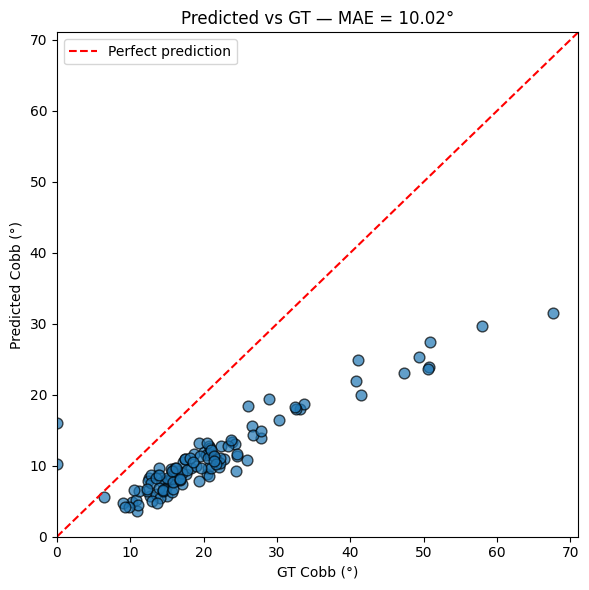

Global MAE (val+test): 10.02°


In [ ]:
all_common = pd.concat([
    df_results.dropna(subset=["cobb", "gt_cobb"])[["cobb", "gt_cobb"]],
    df_test.dropna(subset=["cobb", "gt_cobb"])[["cobb", "gt_cobb"]],
], ignore_index=True)

if len(all_common):
    mae_global = (all_common["cobb"] - all_common["gt_cobb"]).abs().mean()
    lim = float(all_common.max().max()) * 1.05
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(all_common["gt_cobb"], all_common["cobb"], alpha=0.7, edgecolors="k", s=60)
    ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
    ax.set_xlabel("GT Cobb (°)"); ax.set_ylabel("Predicted Cobb (°)")
    ax.set_title(f"Predicted vs GT — MAE = {mae_global:.2f}°"); ax.legend()
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); plt.tight_layout(); plt.show()
    print(f"Global MAE (val+test): {mae_global:.2f}°")
else:
    print("No usable GT — check cell 25 (file format).")

36

In [ ]:
FIG_DIR = Path("/content/thesis_figures"); FIG_DIR.mkdir(exist_ok=True)

def save_fig(name, dpi=300):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    print("Saved:", name)

plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Export ready ->", FIG_DIR)

Export ready -> /content/thesis_figures


37

Table 1:
 Split  N images  N annotations  Categories
Train     16000         273450           1
 Test      4000          68815           1 

Table 2:
 Metric   Mean    Std    Min    Max
   IoU 0.7617 0.0270 0.6893 0.8095
  Dice 0.8616 0.0188 0.8114 0.8932 

Saved: fig_boxplot_iou_dice


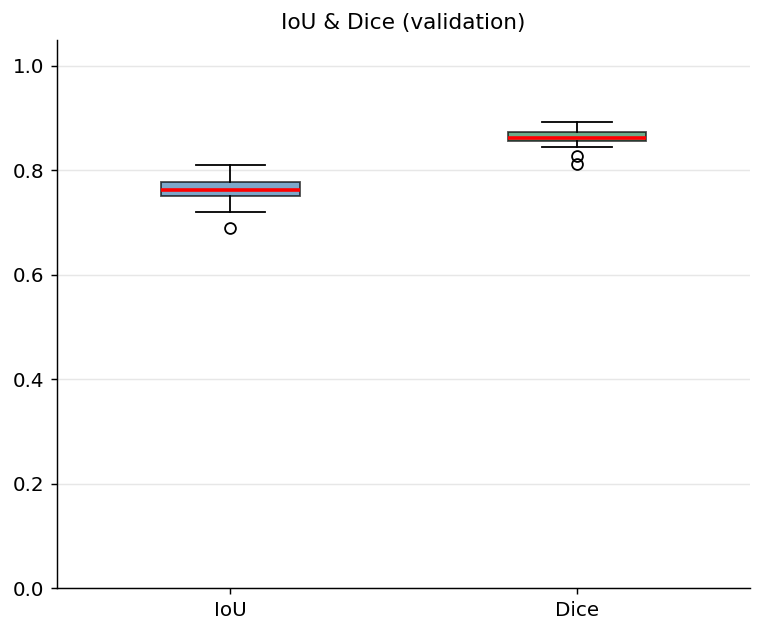

Saved: fig_severity


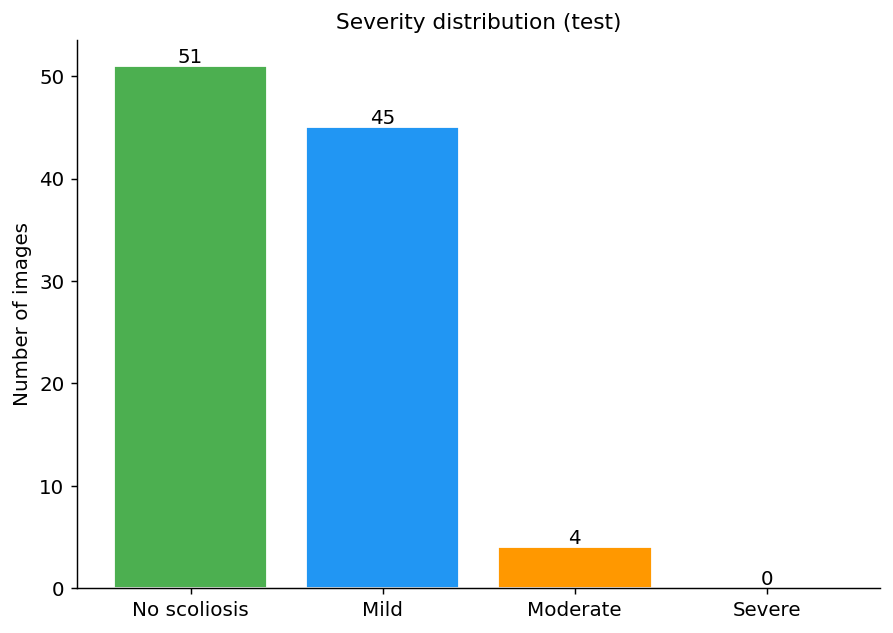

Table 3:
               Metric   Value
      Mean IoU (val)  0.7617
     Mean Dice (val)  0.8616
MAE Cobb vs GT (deg) 10.0200
Mean Cobb test (deg) 11.4100


In [ ]:
df_dataset = pd.DataFrame({
    "Split":         ["Train", "Test"],
    "N images":      [len(images_by_id), len(test_images_by_id)],
    "N annotations": [len(train_data["annotations"]), len(test_data["annotations"])],
    "Categories":    [1, 1],
})
df_dataset.to_csv(FIG_DIR / "table1_dataset.csv", index=False)
print("Table 1:\n", df_dataset.to_string(index=False), "\n")

iou_arr, dice_arr = df_metrics["iou"].values, df_metrics["dice"].values
df_seg = pd.DataFrame({
    "Metric": ["IoU", "Dice"],
    "Mean":   [round(iou_arr.mean(), 4), round(dice_arr.mean(), 4)],
    "Std":    [round(iou_arr.std(), 4),  round(dice_arr.std(), 4)],
    "Min":    [round(iou_arr.min(), 4),  round(dice_arr.min(), 4)],
    "Max":    [round(iou_arr.max(), 4),  round(dice_arr.max(), 4)],
})
df_seg.to_csv(FIG_DIR / "table2_segmentation.csv", index=False)
print("Table 2:\n", df_seg.to_string(index=False), "\n")

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot([iou_arr, dice_arr], tick_labels=["IoU", "Dice"], patch_artist=True,
                medianprops=dict(color="red", lw=2), widths=0.4)
for patch, c in zip(bp["boxes"], ["steelblue", "seagreen"]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylim(0, 1.05); ax.set_title("IoU & Dice (validation)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig("fig_boxplot_iou_dice"); plt.show()

LABELS = ["No scoliosis", "Mild", "Moderate", "Severe"]
COLORS = ["#4caf50", "#2196f3", "#ff9800", "#f44336"]
counts = [int((df_test["severity"] == l).sum()) for l in LABELS]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(LABELS, counts, color=COLORS, edgecolor="white")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, str(c), ha="center", fontsize=11)
ax.set_ylabel("Number of images"); ax.set_title("Severity distribution (test)")
plt.tight_layout(); save_fig("fig_severity"); plt.show()

mae_cobb = (all_common["cobb"] - all_common["gt_cobb"]).abs().mean() if len(all_common) else float("nan")
df_summary = pd.DataFrame([
    ("Mean IoU (val)",        round(iou_arr.mean(), 4)),
    ("Mean Dice (val)",       round(dice_arr.mean(), 4)),
    ("MAE Cobb vs GT (deg)",  round(mae_cobb, 2) if not np.isnan(mae_cobb) else "N/A"),
    ("Mean Cobb test (deg)",  round(df_test["cobb"].dropna().mean(), 2)),
], columns=["Metric", "Value"])
df_summary.to_csv(FIG_DIR / "table3_summary.csv", index=False)
print("Table 3:\n", df_summary.to_string(index=False))

38

In [ ]:
mae_str = f"{mae_cobb:.2f} deg" if not np.isnan(mae_cobb) else "N/A (check cell 25)"
report = f"""{'='*60}
REPORT — SCOLIOSIS DETECTION (Spinal-AI2024) — Mask R-CNN
{'='*60}
1. ARCHITECTURE
   Mask R-CNN (ResNet-50-FPN) pretrained on COCO, fine-tuned on Spinal-AI2024
   Epochs: {len(train_loss_history)} | best val loss: {min(val_loss_history):.4f}

2. DATASET
   Train : {len(images_by_id)} images / {len(train_data['annotations'])} annotations
   Test  : {len(test_images_by_id)} images / {len(test_data['annotations'])} annotations
   Note  : COCO category 'text' (id=1) = vertebral region, remapped to 'vertebra'

3. SEGMENTATION (validation)
   Mean IoU  : {iou_arr.mean():.4f} +/- {iou_arr.std():.4f}
   Mean Dice : {dice_arr.mean():.4f} +/- {dice_arr.std():.4f}

4. COBB ANGLE
   Method : real endplate regression (contour)
   Formula: theta = arctan(|m_u - m_l| / (1 + m_u*m_l))
   MAE vs GT: {mae_str}

5. CLASSIFICATION (test)
   No scoliosis : {int((df_test['severity']=='No scoliosis').sum())}
   Mild         : {int((df_test['severity']=='Mild').sum())}
   Moderate     : {int((df_test['severity']=='Moderate').sum())}
   Severe       : {int((df_test['severity']=='Severe').sum())}
{'='*60}"""
print(report)
(FIG_DIR / "thesis_report.txt").write_text(report, encoding="utf-8")
print("Files exported to:", FIG_DIR)

REPORT — SCOLIOSIS DETECTION (Spinal-AI2024) — Mask R-CNN
1. ARCHITECTURE
   Mask R-CNN (ResNet-50-FPN) pretrained on COCO, fine-tuned on Spinal-AI2024
   Epochs: 1 | best val loss: 0.4884

2. DATASET
   Train : 16000 images / 273450 annotations
   Test  : 4000 images / 68815 annotations
   Note  : COCO category 'text' (id=1) = vertebral region, remapped to 'vertebra'

3. SEGMENTATION (validation)
   Mean IoU  : 0.7617 +/- 0.0270
   Mean Dice : 0.8616 +/- 0.0188

4. COBB ANGLE
   Method : real endplate regression (contour)
   Formula: theta = arctan(|m_u - m_l| / (1 + m_u*m_l))
   MAE vs GT: 10.02 deg

5. CLASSIFICATION (test)
   No scoliosis : 51
   Mild         : 45
   Moderate     : 4
   Severe       : 0
Files exported to: /content/thesis_figures
